In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from astropy.cosmology import FlatLambdaCDM

In [8]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_chi2_only.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 69 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    521 non-null    float64
 1   ztfname                           521 non-null    object 
 2   ZTF_redshift                      521 non-null    float64
 3   ZTF_redshift_err                  521 non-null    float64
 4   ZTF_source                        521 non-null    object 
 5   ZTF_t0                            521 non-null    float64
 6   ZTF_x0                            521 non-null    float64
 7   ZTF_x1                            521 non-null    float64
 8   ZTF_c                             521 non-null    float64
 9   ZTF_t0_err                        521 non-null    float64
 10  ZTF_x0_err                        521 non-null    float64
 11  ZTF_x1_err                        521 non-null    float64
 12  ZTF_c_er

In [9]:
feature_cols = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

target_col = "residuals"

X = df[feature_cols]
y = df[target_col]

DESI_FASTSPEC_g_minus_r    0.251181
DESI_METADATA_Z            0.191125
DESI_FASTSPEC_LOGMSTAR     0.150162
DESI_FASTSPEC_DN4000       0.126905
DESI_FASTSPEC_VDISP        0.098316
DESI_FASTSPEC_AGE          0.091237
DESI_FASTSPEC_SFR          0.091073
dtype: float64


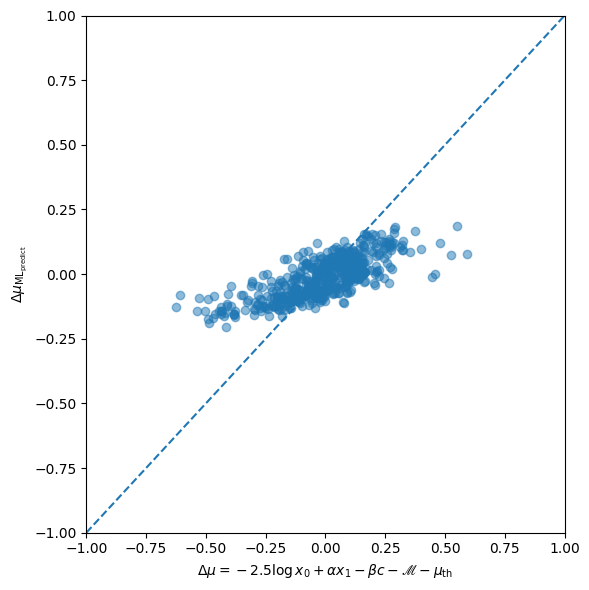

In [10]:
best_params = {'n_estimators': 900, 'max_depth': 14, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True, 'max_samples': 0.801423245872187}
best_params["n_jobs"] = -1
best_params["random_state"] = 42 # Keeps data reproducible

rf = RandomForestRegressor(**best_params)
rf.fit(X, y)
y_pred = rf.predict(X)

feature_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(feature_importances)

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel(r"$\Delta\mu = -2.5\log x_0 + \alpha x_1 - \beta c - \mathscr{M} - \mu_{\rm th}$")
plt.ylabel(r"$\Delta\mu_{\mathrm{ML}_{\mathrm{predict}}}$")
plt.axline((0, 0), slope=1, linestyle="--")

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()



$\Delta\mu_{\rm corrected} = \left(-2.5\log x_0 + \alpha x_1 - \beta c - \mathscr{M} - \mu_{\rm th}\right) - \Delta\mu_{\rm ML, predict}$



In [11]:
#Because you did rf.predict(X) where X = df[feature_cols]. The prediction follows the same row order as the dataframe. 
# Row 0 of y_pred corresponds to row 0 of df. Row 1 to row 1. And so on.

corrected_residuals = df["residuals"] - y_pred

rms_corrected = np.sqrt(np.mean(corrected_residuals ** 2))

print("RMS of corrected residuals:", rms_corrected)

RMS of corrected residuals: 0.13736949876902202


$\Delta\mu = -2.5\log x_0 + \alpha x_1 - \beta c - \mathscr{M} - \mu_{\rm th}$

In [12]:

rms_corrected = np.sqrt(np.mean(df["residuals"] ** 2))
print("RMS of corrected residuals:", rms_corrected)

RMS of corrected residuals: 0.18666577682295912
